# PigeonPilot — Reservoir A vs B

**Research question:** Does STDP in a recurrent LIF reservoir improve path integration
compared to a fixed (non-plastic) reservoir?

| Model | Reservoir | Readout |
|-------|-----------|---------|
| **A** | Fixed dense recurrent LIF | `RidgeClassifier` → home heading bin |
| **B** | Same init + STDP (`WeightDependentPostPre`) | same |

**Jury metric:** circular bin error × 10° (not X/Y MSE).

### Step 1: Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from sklearn.linear_model import RidgeClassifier

import sys
import types

# Compatibility shim for bindsnet's outdated torch._six import
six_shim = types.ModuleType("torch._six")
six_shim.string_classes = (str,)
six_shim.int_classes = (int,)
six_shim.inf = float("inf")
sys.modules["torch._six"] = six_shim

from bindsnet.network import Network
from bindsnet.network.nodes import Input, LIFNodes
from bindsnet.network.topology import Connection
from bindsnet.network.monitors import Monitor
from bindsnet.learning import WeightDependentPostPre

from pigeonpilot.paths import (
    STYLES,
    DIFFICULTIES,
    DEFAULT_HEADING_BINS,
    FULL_CIRCLE_DEG,
    Segment,
    generate_level,
)
from pigeonpilot.encoding import (
    encode_level,
    compass_bin,
    heading_to_bin,
    plan_encoding,
)
from pigeonpilot.curriculum import (
    DEFAULT_EPOCHS_PER_DIFFICULTY,
    curriculum_level_count,
    format_curriculum_table,
    format_style_labels_table,
    generate_curriculum_dataset,
    split_dataset,
    summarize_dataset,
    iter_train_schedule,
)
from pigeonpilot.viz import (
    plot_level,
    plot_level_encoding,
    plot_body_ring_anatomy,
    plot_level_ring_frames,
    plot_levels_grid,
    plot_release_points,
    compute_xy_limits,
    plot_spike_raster,
)

print("imports ok")
print("torch", torch.__version__)
print("trajectory families:", STYLES)
display(Markdown("### Trajectory family labels (`STYLE_LABELS`)"))
display(Markdown(format_style_labels_table()))

imports ok
torch 2.13.0
trajectory families: ('linear', 'turning', 'curved')


### Trajectory family labels (`STYLE_LABELS`)

| Name | Meaning |
|------|---------|
| `linear` | straight / direct |
| `turning` | heading jumps (turns) |
| `curved` | wave or sweeping arc |

### Step 2: Create Dataset

In [16]:
DATASET_SEED = 42
SPLIT_SEED = 0
EXPECTED_N = curriculum_level_count()

dataset = generate_curriculum_dataset(seed=DATASET_SEED)
print(summarize_dataset(dataset))
assert len(dataset) == EXPECTED_N, f"expected {EXPECTED_N}, got {len(dataset)}"

train_set, test_set = split_dataset(dataset, train_frac=0.8, seed=SPLIT_SEED)
print(f"train: {len(train_set)} | test: {len(test_set)}")

xlim_global, ylim_global = compute_xy_limits(dataset)

# For visualization remove the comment
#
# for difficulty in DIFFICULTIES:
#     subset = [lv for lv in dataset if lv.difficulty == difficulty]
#     plot_levels_grid(subset, title=f"Difficulty: {difficulty}")
#     plt.show()

{'total': 150, 'by_difficulty': {'easy': 60, 'medium': 60, 'hard': 30}, 'by_style': {'linear': 30, 'turning': 75, 'curved': 45}}
train: 120 | test: 30


### Step 3: Hyperparameters and Helper Methods

In [76]:
# --- hyperparameters ---

# --- network structure ---
N_INPUT_NODES = DEFAULT_HEADING_BINS  # number of nodes in the input layer -> 36
N_RESERVOIR_NODES = 1000 # number of nodes in the reservoir
NETWORK_DT = 1.0 # simulation step size (1ms)

# --- endcoding ---
ENCODING_DT = 0.05  # longer spike trains than dt=1 # TODO why?
ENCODING_VELOCITY = 1.0
TRAILING_SILENCE = 20  # zeros added to input spikes, so that the reservoir has time to compute

# --- weight initialization ---
WEIGHT_SEED = 0
# FEEDFORWARD_SCALE = 0.8
FEEDFORWARD_STRENGTH = 20 # normalization constant - the total strength that will go into the reservoir
RESERVOIR_SCALE = 0.9  # scaling constant for the recurrent connections in the reservoir
WMIN, WMAX = 0.0, 1.0  # STDP bounds; pair with small STDP_NU

# --- learning parameters ---
LIF_KW = dict(rest=-65.0, reset=-65.0, thresh=-52.0, refrac=5) # defines LIF values that can be reused with **LIF
STDP_NU =(1e-5, 1e-3)  # learning rate for STDP
STDP_TC_PRE = 20.0 # pre-synaptic trace time constant of 20 ms for STDP
STDP_TC_POST = 20.0 # post-synaptic trace time constant of 20 ms for STDP

# Plasticity schedule (shorter than DEFAULT for hackathon runtime; raise for full runs)
STDP_EPOCHS_PER_DIFFICULTY = {"easy": 80, "medium": 50, "hard": 30}

# --- readout function: Ridge Regression ---
RIDGE_ALPHA = 1.0


def home_heading_deg(home_xy) -> float:
    """Compass degrees of the home vector (0°=N/+y, 90°=E/+x)."""
    x, y = float(home_xy[0]), float(home_xy[1])
    return float(np.degrees(np.arctan2(x, y)) % FULL_CIRCLE_DEG)


def home_bin(level, heading_bins: int = DEFAULT_HEADING_BINS) -> int:
    """Classification label: heading bin of home_xy."""
    return compass_bin(home_heading_deg(level.home_xy), heading_bins)


def circular_bin_error(
    true_bin: int,
    pred_bin: int,
    heading_bins: int = DEFAULT_HEADING_BINS,
) -> tuple[int, float]:
    """Return (bin_error, degrees)."""
    d = abs(int(true_bin) - int(pred_bin)) % heading_bins
    d = min(d, heading_bins - d)
    return d, d * (FULL_CIRCLE_DEG / heading_bins)


def encode_level_for_network(level) -> np.ndarray:
    # Encodes a level object into a spike train using encode_level(...) - as numpy array - and adds zeros to the end of length TRAILING_SILENCE, so the reservoir has time to compute
    spikes = encode_level(
        level, velocity=ENCODING_VELOCITY, dt=ENCODING_DT, heading_bins=N_INPUT_NODES
    )
    if TRAILING_SILENCE > 0:
        pad = np.zeros((TRAILING_SILENCE, N_INPUT_NODES), dtype=np.float32)
        spikes = np.vstack([spikes, pad])
    return spikes


def to_bindsnet_input(spikes: np.ndarray) -> torch.Tensor:
    # Converts the already computed spike input from a numpy array into a torch tensor
    return torch.from_numpy(np.asarray(spikes, dtype=np.float32)).unsqueeze(1)


def pool_reservoir_state(spike_tensor: torch.Tensor) -> np.ndarray:
    # retrieves the mean firing rate of each reservoir neuron across the entire trial
    return spike_tensor.float().mean(dim=0).squeeze(0).detach().cpu().numpy()

def run_trial(net: Network, level, learning: bool) -> np.ndarray:
    """Encode → run → pool state → reset. Returns pooled reservoir rates."""
    spikes = encode_level_for_network(level) # encodes the raw x,y coordinates of the level into spikes of 36 neurons where each spikes when its assigned position is pointed northwards. Math for this calculation is in encoding.py and paths.py
    inputs = to_bindsnet_input(spikes) # convert from numpy array to torch tensor
    net.train(learning) # toggles plasticity on or off
    net.run(inputs={"Input": inputs}, time=spikes.shape[0]) # gives the input to the network and lets it run
    state = pool_reservoir_state(net.monitors["Reservoir Spikes"].get("s")) # gets the mean firing rate of each reservoir neuron from the monitoring
    net.reset_state_variables() # resets the state of the network (learned weights stay)
    return state


# Sanity: South home ≈ bin 18; pred bin 19 → 1 bin = 10°
_south = type("L", (), {"home_xy": (0.0, -1.0)})()
assert home_bin(_south) == 18, home_bin(_south)
bins_err, deg_err = circular_bin_error(18, 19)
assert bins_err == 1 and deg_err == 10.0, (bins_err, deg_err)
print("helpers ok | ENCODING_DT=", ENCODING_DT, "| TRAILING_SILENCE=", TRAILING_SILENCE)
print("example train home_bin:", home_bin(train_set[0]), "heading°:", round(home_heading_deg(train_set[0].home_xy), 1))

helpers ok | ENCODING_DT= 0.05 | TRAILING_SILENCE= 20
example train home_bin: 12 heading°: 120.0


### Step 4: Build 2 Networks
`network_a` without plasticity and `network_b` with plasticity

In [77]:
def init_weights(n_input: int, n_res: int, seed: int = WEIGHT_SEED):
    # n_input: number of input neurons
    # n_res: number of reservoir neurons
    # seed: random seed

    generator = torch.Generator().manual_seed(seed)

    # Initializing feedforward weights
    feedforward_weights = torch.rand(n_input, n_res, generator=generator)
    normalized_feedforward_weights = FEEDFORWARD_STRENGTH * feedforward_weights / feedforward_weights.sum(dim=0, keepdim=True)

    # Initializing reservoir weights
    reservoir_weights = torch.rand(n_res, n_res, generator=generator)
    reservoir_weights.fill_diagonal_(0.0) # removes self connections

    # Spectral radius = largest eigenvalue of the recurrent weight matrix.
    # It controls whether signals grow (>1), decay (<1), or persist (~1) as they
    # loop through the reservoir, so we rescale the matrix to hit the target value RESERVOIR_SCALE.
    spectral_radius = torch.linalg.eigvals(reservoir_weights).abs().max().item() # Spectral radius control to
    scaled_reservoir_weights = reservoir_weights * (RESERVOIR_SCALE / spectral_radius)

    return normalized_feedforward_weights, scaled_reservoir_weights


def build_reservoir(
    *,
    plastic: bool,
    w_ff: torch.Tensor,
    w_res: torch.Tensor,
    dt: float = NETWORK_DT,
) -> Network:
    # Builds a reservoir network
    # plastic: if set to true, it will add plasticity with STDP
    # w_ff: Initial Feedforward weights
    # w_res: Initial recurrent Reservoir weights
    # dt: simulation step size
    n_input, n_res = w_ff.shape
    assert w_res.shape == (n_res, n_res)

    network = Network(dt=dt)
    input_layer = Input(n=n_input, traces=True)
    reservoir = LIFNodes(n=n_res, traces=True, **LIF_KW) # **LIF_KW uses the earlier declared values from LIF_KW = ...
    network.add_layer(input_layer, name="Input")
    network.add_layer(reservoir, name="Reservoir")

    conn_kwargs = dict(wmin=WMIN, wmax=WMAX)

    # If plastic = true, we want to add STDP parameters
    if plastic:
        conn_kwargs.update(
            update_rule=WeightDependentPostPre,
            nu=STDP_NU,
            tc_pre=STDP_TC_PRE,
            tc_post=STDP_TC_POST,
        )

    feedforward_connection = Connection(
        source=input_layer,
        target=reservoir,
        w=w_ff.clone(),
        **conn_kwargs,
    )
    reservoir_connection = Connection(
        source=reservoir,
        target=reservoir,
        w=w_res.clone(),
        **conn_kwargs,
    )
    network.add_connection(feedforward_connection, source="Input", target="Reservoir")
    network.add_connection(reservoir_connection, source="Reservoir", target="Reservoir")

    network.add_monitor(
        Monitor(obj=reservoir, state_vars=["s"], time=None),
        name="Reservoir Spikes",
    )
    return network


initial_feedforward_weights, initial_reservoir_weights = init_weights(N_INPUT_NODES, N_RESERVOIR_NODES, seed=WEIGHT_SEED)
network_a = build_reservoir(plastic=False, w_ff=initial_feedforward_weights, w_res=initial_reservoir_weights)
network_b = build_reservoir(plastic=True, w_ff=initial_feedforward_weights, w_res=initial_reservoir_weights)

# identical start weights
assert torch.allclose(
    network_a.connections[("Input", "Reservoir")].w,
    network_b.connections[("Input", "Reservoir")].w,
)
assert torch.allclose(
    network_a.connections[("Reservoir", "Reservoir")].w,
    network_b.connections[("Reservoir", "Reservoir")].w,
)
assert torch.count_nonzero(
    torch.diag(network_a.connections[("Reservoir", "Reservoir")].w)
) == 0

print(network_a)
print("A plastic rules:", {k: c.update_rule for k, c in net_a.connections.items()})
print("B plastic rules:", {k: type(c.update_rule).__name__ if c.update_rule else None for k, c in net_b.connections.items()})
print("w_ff mean", float(initial_feedforward_weights.mean()), "| w_rec mean (off-diag)", float(initial_reservoir_weights[~torch.eye(N_RESERVOIR_NODES, dtype=bool)].mean()))

Network(
  (Input): Input()
  (Reservoir): LIFNodes()
  (Input_to_Reservoir): Connection(
    (source): Input()
    (target): LIFNodes()
  )
  (Reservoir_to_Reservoir): Connection(
    (source): LIFNodes()
    (target): LIFNodes()
  )
)
A plastic rules: {('Input', 'Reservoir'): <bindsnet.learning.learning.NoOp object at 0x13a9d1940>, ('Reservoir', 'Reservoir'): <bindsnet.learning.learning.NoOp object at 0x13a9ff390>}
B plastic rules: {('Input', 'Reservoir'): 'WeightDependentPostPre', ('Reservoir', 'Reservoir'): 'WeightDependentPostPre'}
w_ff mean 0.5555555820465088 | w_rec mean (off-diag) 0.0009009111090563238


### Step 5: Smoke-test one easy level
feed one level to Network A and monitor the output of the reservoir neurons

smoke level_id=0 T=53 home_bin=12 res_spikes=710 active=605/1000


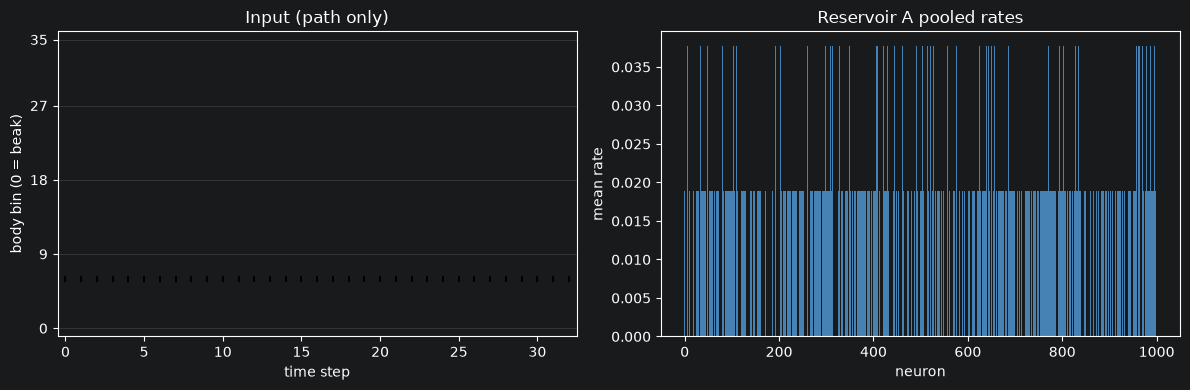

smoke ok


In [78]:
smoke_level = next(lv for lv in train_set if lv.difficulty == "easy")
smoke_spikes = encode_level_for_network(smoke_level)
smoke_input = to_bindsnet_input(smoke_spikes)
T_smoke = smoke_spikes.shape[0]

network_a.train(False)
network_a.run(inputs={"Input": smoke_input}, time=T_smoke)
s_a = network_a.monitors["Reservoir Spikes"].get("s")
state_a = pool_reservoir_state(s_a)
print(
    f"smoke level_id={smoke_level.level_id} T={T_smoke} "
    f"home_bin={home_bin(smoke_level)} "
    f"res_spikes={float(s_a.sum()):.0f} "
    f"active={(state_a > 0).sum()}/{N_RESERVOIR_NODES}"
)
assert s_a.sum() > 0, "Reservoir A produced no spikes — raise FF_SCALE or ENCODING length"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_spike_raster(smoke_spikes[: max(1, T_smoke - TRAILING_SILENCE)], ax=axes[0], title="Input (path only)")
axes[1].bar(np.arange(N_RESERVOIR_NODES), state_a, width=1.0, color="steelblue")
axes[1].set_title("Reservoir A pooled rates")
axes[1].set_xlabel("neuron")
axes[1].set_ylabel("mean rate")
plt.tight_layout()
plt.show()

network_a.reset_state_variables()
print("smoke ok")

### Step 6: STDP
Introduce plasticity to Network B

In [79]:
feedforward_weights_before = network_b.connections[("Input", "Reservoir")].w.detach().clone()
reservoir_weights_before = network_b.connections[("Reservoir", "Reservoir")].w.detach().clone()

current_trial = 0
print("STDP Curriculum - epochs per difficulty:", STDP_EPOCHS_PER_DIFFICULTY)

# In the dataset we have 3 difficulty levels - easy, medium, hard.
# Each of those is presented once in each epoch,

for phase, phase_epoch, _, level in iter_train_schedule(
    train_set,
    mode="curriculum",
    epochs_per_difficulty=STDP_EPOCHS_PER_DIFFICULTY,
    seed=0,
):
    # phase — current difficulty "easy", "medium", or "hard"
    # phase_epoch — the epoch number within the current phase (starts at 0 for each new difficulty)
    # level — the actual Level object being presented this trial
    run_trial(network_b, level, learning=True)
    current_trial += 1
    if current_trial % 100 == 0:
        print(f"  ... {current_trial} plastic trials (phase={phase}, epoch={phase_epoch})")

network_b.train(False)

feedforward_weights_after = network_b.connections[("Input", "Reservoir")].w.detach()
reservoir_weights_after = network_b.connections[("Reservoir", "Reservoir")].w.detach()
ff_delta = float((feedforward_weights_after - feedforward_weights_before).abs().mean())
rec_delta = float((reservoir_weights_after - reservoir_weights_before).abs().mean())
print(f"plastic trials: {current_trial}")
print(f"mean |Δw| FF={ff_delta:.6f}  Rec={rec_delta:.6f}")
assert ff_delta > 0 or rec_delta > 0, "STDP did not change weights"
print("Model B frozen for readout")

STDP Curriculum - epochs per difficulty: {'easy': 80, 'medium': 50, 'hard': 30}
  ... 100 plastic trials (phase=easy, epoch=2)
  ... 200 plastic trials (phase=easy, epoch=4)


KeyboardInterrupt: 

### Step 7: Collect states + fit RidgeClassifier (A and B)

Target = `home_bin(level)` ∈ {0…35}.

In [71]:
def collect_states(net: Network, levels) -> tuple[np.ndarray, np.ndarray, list]:
    # runs the network on all levels in the set returning 3 lists:
    # X: the reservoir firing, y: the correct label as the bin in the home direction, difficulties: the difficulty of the level
    X, y, difficulties = [], [], []
    for i, level in enumerate(levels):
        state = run_trial(net, level, learning=False)
        X.append(state)
        y.append(home_bin(level))
        difficulties.append(level.difficulty)
        if (i + 1) % 40 == 0:
            print(f"  collected {i + 1}/{len(levels)}")
    return np.asarray(X, dtype=np.float64), np.asarray(y, dtype=np.int64), difficulties


print("Collecting train states — Model A")
X_train_a, y_train_a, _ = collect_states(network_a, train_set)
print("Collecting train states — Model B")
X_train_b, y_train_b, _ = collect_states(network_b, train_set)

print("Collecting test states — Model A")
X_test_a, y_test_a, test_diffs = collect_states(network_a, test_set)
print("Collecting test states — Model B")
X_test_b, y_test_b, _ = collect_states(network_b, test_set)

assert np.array_equal(y_train_a, y_train_b)
assert np.array_equal(y_test_a, y_test_b)
print("unique train bins:", len(np.unique(y_train_a)), "/ 36")

classifier_a = RidgeClassifier(alpha=RIDGE_ALPHA)
classifier_b = RidgeClassifier(alpha=RIDGE_ALPHA)
classifier_a.fit(X_train_a, y_train_a)
classifier_b.fit(X_train_b, y_train_b)
print("RidgeClassifiers fitted")

  collected 40/120
  collected 80/120
  collected 120/120
  collected 40/120
  collected 80/120
  collected 120/120
unique train bins: 34 / 36
RidgeClassifiers fitted


### Step 8: Evaluation — circular angular error

In [75]:
def angular_errors(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # calculates the error between prediction and true value in a circular disctance, because 10 degrees is close to 350 degrees
    bins_err = np.empty(len(y_true), dtype=np.int64)
    degrees_err = np.empty(len(y_true), dtype=np.float64)
    for i, (true_value, predicted_value) in enumerate(zip(y_true, y_pred)):
        bin_error, direction_error = circular_bin_error(int(true_value), int(predicted_value))
        bins_err[i] = bin_error
        degrees_err[i] = direction_error
    return bins_err, degrees_err

# predictions of both models on the test set
pred_a = classifier_a.predict(X_test_a)
pred_b = classifier_b.predict(X_test_b)

# errors of both models on the test set in bins and degrees
bins_error_a, degrees_error_a = angular_errors(y_test_a, pred_a)
bins_error_b, degrees_error_b = angular_errors(y_test_b, pred_b)

# accuracy - how many were correctly guessed - of both models on the test set
accuracy_a = float((pred_a == y_test_a).mean())
accuracy_b = float((pred_b == y_test_b).mean())

summary = {
    "A": {"mean_deg": float(degrees_error_a.mean()), "std_deg": float(degrees_error_a.std()), "exact_acc": accuracy_a},
    "B": {"mean_deg": float(degrees_error_b.mean()), "std_deg": float(degrees_error_b.std()), "exact_acc": accuracy_b},
}

print("=== Test angular error (circular) ===")
print(
    f"Pigeon A (fixed):  mean error {summary['A']['mean_deg']:.1f}° ± {summary['A']['std_deg']:.1f}°  "
    f"| exact-bin acc {100 * accuracy_a:.1f}%"
)
print(
    f"Pigeon B (STDP):   mean error {summary['B']['mean_deg']:.1f}° ± {summary['B']['std_deg']:.1f}°  "
    f"| exact-bin acc {100 * accuracy_b:.1f}%"
)

print("\nBy difficulty (mean °):")
for diff in DIFFICULTIES:
    mask = np.array([d == diff for d in test_diffs])
    if not mask.any():
        continue
    print(
        # n is the number of tests for the specific difficulty
        f"  {diff:8s}  A={degrees_error_a[mask].mean():5.1f}°   B={degrees_error_b[mask].mean():5.1f}°   n={mask.sum()}"
    )

=== Test angular error (circular) ===
Pigeon A (fixed):  mean error 33.0° ± 31.2°  | exact-bin acc 10.0%
Pigeon B (STDP):   mean error 35.7° ± 37.5°  | exact-bin acc 10.0%

By difficulty (mean °):
  easy      A= 21.7°   B= 21.7°   n=12
  medium    A= 26.7°   B= 33.3°   n=12
  hard      A= 68.3°   B= 68.3°   n=6


### Step 9: Jury comparison plots
- Diagram 1 shows the overall mean angular error of both networks
- Diagram 2 shows in how many tests (y-axis) each network was off by how many degrees (x-axis)
- Diagram 3 shows the mean error of both networks per level difficulty

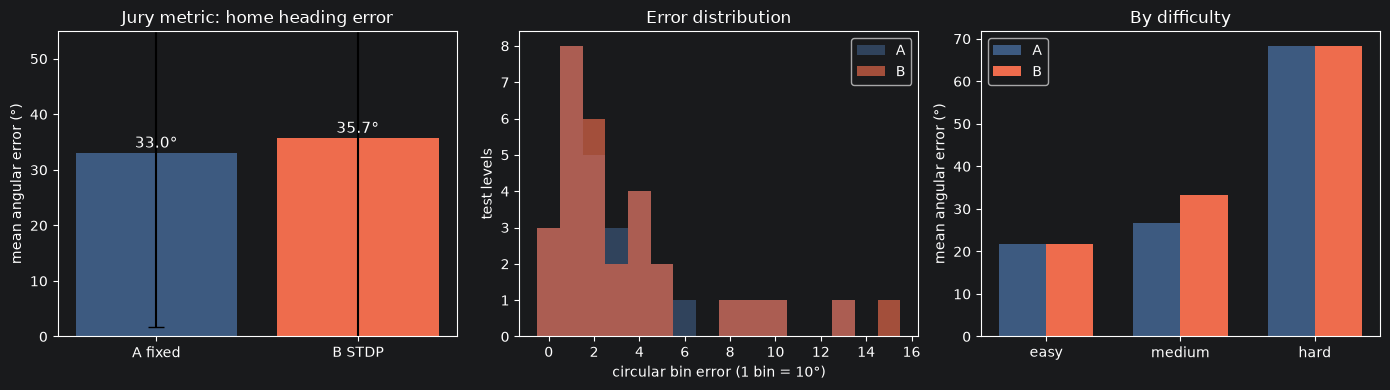

Headline: Pigeon A 33° vs Pigeon B 36° → better: A (fixed)
Interpretation: STDP may overwrite the reservoir's fading short-term memory.


In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Mean angular error bar
ax = axes[0]
means = [summary["A"]["mean_deg"], summary["B"]["mean_deg"]]
stds = [summary["A"]["std_deg"], summary["B"]["std_deg"]]
bars = ax.bar(["A fixed", "B STDP"], means, yerr=stds, color=["#3d5a80", "#ee6c4d"], capsize=6)
ax.set_ylabel("mean angular error (°)")
ax.set_title("Jury metric: home heading error")
ax.set_ylim(0, max(means) * 1.4 + 5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 1, f"{m:.1f}°", ha="center", fontsize=11)

# 2) Histogram of bin errors
ax = axes[1]
max_bin = max(int(bins_error_a.max()), int(bins_error_b.max()), 1)
bins_edges = np.arange(0, max_bin + 2) - 0.5
ax.hist(bins_error_a, bins=bins_edges, alpha=0.65, label="A", color="#3d5a80")
ax.hist(bins_error_b, bins=bins_edges, alpha=0.65, label="B", color="#ee6c4d")
ax.set_xlabel("circular bin error (1 bin = 10°)")
ax.set_ylabel("test levels")
ax.set_title("Error distribution")
ax.legend()

# 3) Per-difficulty means
ax = axes[2]
x = np.arange(len(DIFFICULTIES))
width = 0.35
means_a_d, means_b_d = [], []
for diff in DIFFICULTIES:
    mask = np.array([d == diff for d in test_diffs])
    means_a_d.append(float(degrees_error_a[mask].mean()) if mask.any() else 0.0)
    means_b_d.append(float(degrees_error_b[mask].mean()) if mask.any() else 0.0)
ax.bar(x - width / 2, means_a_d, width, label="A", color="#3d5a80")
ax.bar(x + width / 2, means_b_d, width, label="B", color="#ee6c4d")
ax.set_xticks(x)
ax.set_xticklabels(DIFFICULTIES)
ax.set_ylabel("mean angular error (°)")
ax.set_title("By difficulty")
ax.legend()

plt.tight_layout()
plt.show()

winner = "A (fixed)" if summary["A"]["mean_deg"] <= summary["B"]["mean_deg"] else "B (STDP)"
print(
    f"Headline: Pigeon A {summary['A']['mean_deg']:.0f}° vs Pigeon B {summary['B']['mean_deg']:.0f}° "
    f"→ better: {winner}"
)
if summary["A"]["mean_deg"] < summary["B"]["mean_deg"]:
    print("Interpretation: STDP may overwrite the reservoir's fading short-term memory.")
else:
    print("Interpretation: STDP appears to help (or not hurt) path-integration readout.")